# Clasificadores sobre Iris — LDA, K-NN y Árbol de decisión

**Juan David Sierra Orozco**
Inteligencia Artificial (SI3003), EAFIT — Semana 7

## Enunciado

Desarrollar un clasificador para el dataset Iris (incluido en scikit-learn) con partición 70/30, comparando tres algoritmos:

1. **LDA** (Linear Discriminant Analysis)
2. **K-NN** con k=3
3. **Árbol de decisión**

Se deben mostrar las **fronteras de decisión** de cada modelo y sus **métricas de desempeño**, incluyendo cuántos casos clasificó bien y mal.

## El dataset

Iris tiene 150 flores de 3 especies (*setosa*, *versicolor*, *virginica*), 50 de cada una, descritas por 4 medidas: largo y ancho del sépalo, largo y ancho del pétalo. Es el dataset de juguete más clásico de ML porque *setosa* se separa trivialmente de las otras dos, mientras que *versicolor* y *virginica* se solapan un poco. Ese solapamiento es justo lo que va a diferenciar a los tres clasificadores.

## Sobre las fronteras de decisión

Una frontera de decisión se dibuja en 2D, y Iris tiene 4 características. Por eso el notebook hace dos cosas:

- **Métricas con las 4 características**, que es el resultado real y el que se reporta como desempeño del clasificador.
- **Fronteras de decisión con solo 2 características** (largo y ancho del pétalo, las que mejor separan las especies), que es lo que se puede dibujar. Se incluyen también sus métricas por separado, para ver cuánto se pierde al reducir información.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

np.random.seed(42)

---

## 1. Cargar y explorar los datos

Muestras: 150   características: 4
Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Muestras por clase: [50 50 50]


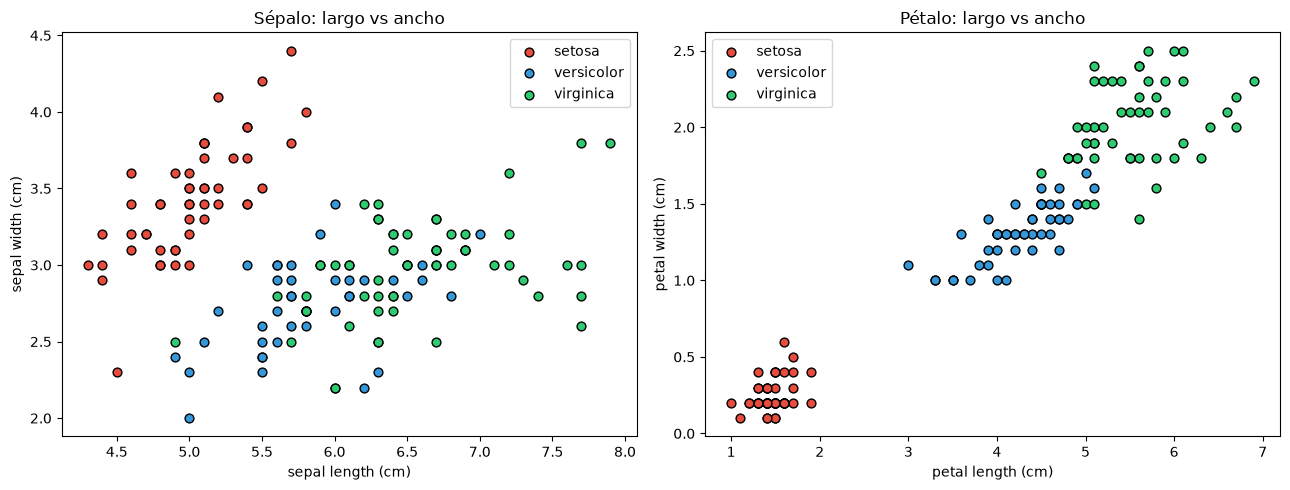

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
NOMBRES_CLASE = iris.target_names
NOMBRES_FEATURE = iris.feature_names

print(f"Muestras: {X.shape[0]}   características: {X.shape[1]}")
print(f"Clases: {list(NOMBRES_CLASE)}")
print(f"Muestras por clase: {np.bincount(y)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = ["#e74c3c", "#3498db", "#2ecc71"]

for c in range(3):
    m = y == c
    axes[0].scatter(X[m, 0], X[m, 1], c=colores[c], label=NOMBRES_CLASE[c], edgecolor="k", s=40)
    axes[1].scatter(X[m, 2], X[m, 3], c=colores[c], label=NOMBRES_CLASE[c], edgecolor="k", s=40)

axes[0].set_xlabel(NOMBRES_FEATURE[0]); axes[0].set_ylabel(NOMBRES_FEATURE[1])
axes[0].set_title("Sépalo: largo vs ancho"); axes[0].legend()
axes[1].set_xlabel(NOMBRES_FEATURE[2]); axes[1].set_ylabel(NOMBRES_FEATURE[3])
axes[1].set_title("Pétalo: largo vs ancho"); axes[1].legend()
plt.tight_layout(); plt.show()

Con los pétalos las tres especies quedan mucho más separadas que con los sépalos. *Setosa* (rojo) es trivial en cualquiera de los dos casos; *versicolor* y *virginica* se solapan sobre todo en el gráfico del sépalo. Por eso las fronteras de decisión más adelante se dibujan sobre pétalo largo y ancho.

---

## 2. Partición 70/30

Se separa con estratificación, para que la proporción de cada especie sea la misma en entrenamiento y en prueba.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X):.0%})")
print(f"Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X):.0%})")
print(f"\nDistribución en prueba: {np.bincount(y_test)} (una por cada clase, 15/15/15)")

Entrenamiento: 105 muestras (70%)
Prueba:        45 muestras (30%)

Distribución en prueba: [15 15 15] (una por cada clase, 15/15/15)


---

## 3. Los tres clasificadores

**LDA.** Asume que cada clase sigue una normal multivariada con la misma matriz de covarianza, y separa con fronteras lineales que maximizan la separación entre clases relativa a la dispersión dentro de cada una.

**K-NN (k=3).** No asume ninguna forma para las clases. Para clasificar un punto nuevo mira a sus 3 vecinos más cercanos en el espacio de características y vota por mayoría.

**Árbol de decisión.** Parte el espacio con cortes perpendiculares a los ejes, uno por uno, eligiendo en cada paso el corte que más reduce la impureza de las clases.

Los tres se entrenan primero con las **4 características**, que es el resultado que se reporta como desempeño real.

In [4]:
modelos = {
    "LDA": LinearDiscriminantAnalysis(),
    "K-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Árbol de decisión": DecisionTreeClassifier(random_state=42),
}

predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    predicciones[nombre] = modelo.predict(X_test)

print("Modelos entrenados con las 4 características.")

Modelos entrenados con las 4 características.


---

## 4. Métricas: cuántos acertó y cuántos falló cada modelo

In [5]:
print(f"{'modelo':<20} | {'exactitud':>9} | {'correctos':>9} | {'incorrectos':>11}")
print("-" * 58)

resumen = {}
for nombre, pred in predicciones.items():
    acc = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)
    correctos = int(cm.trace())
    incorrectos = int(cm.sum() - correctos)
    resumen[nombre] = dict(acc=acc, correctos=correctos, incorrectos=incorrectos, cm=cm)
    print(f"{nombre:<20} | {acc:>8.1%} | {correctos:>9} | {incorrectos:>11}")

modelo               | exactitud | correctos | incorrectos
----------------------------------------------------------
LDA                  |    97.8% |        44 |           1
K-NN (k=3)           |    95.6% |        43 |           2
Árbol de decisión    |    93.3% |        42 |           3


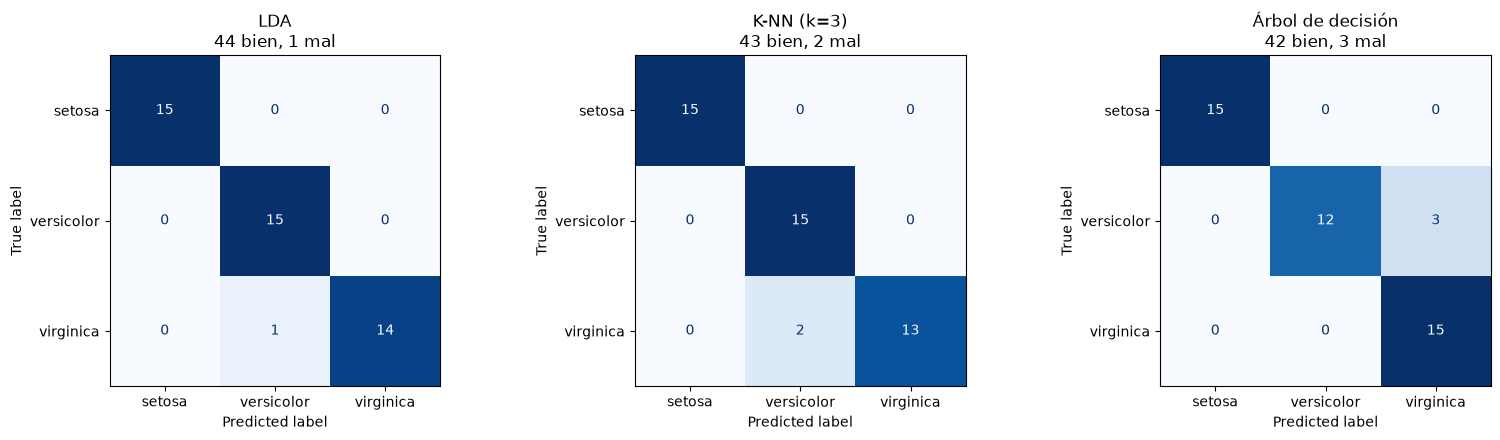

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nombre, pred) in zip(axes, predicciones.items()):
    cm = resumen[nombre]["cm"]
    disp = ConfusionMatrixDisplay(cm, display_labels=NOMBRES_CLASE)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nombre}\n{resumen[nombre]['correctos']} bien, "
                f"{resumen[nombre]['incorrectos']} mal")

plt.tight_layout()
plt.show()

Las matrices de confusión muestran exactamente dónde se equivoca cada modelo. La diagonal son los aciertos; todo lo que queda fuera de la diagonal es una especie confundida con otra. Ninguno de los tres se equivoca nunca con *setosa*: los errores, cuando aparecen, están siempre entre *versicolor* y *virginica*, la zona que se veía solapada en el gráfico de los pétalos.

In [7]:
for nombre, pred in predicciones.items():
    print(f"\n{'='*60}\n{nombre}\n{'='*60}")
    print(classification_report(y_test, pred, target_names=NOMBRES_CLASE, digits=3))


LDA
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.938     1.000     0.968        15
   virginica      1.000     0.933     0.966        15

    accuracy                          0.978        45
   macro avg      0.979     0.978     0.978        45
weighted avg      0.979     0.978     0.978        45


K-NN (k=3)
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.882     1.000     0.938        15
   virginica      1.000     0.867     0.929        15

    accuracy                          0.956        45
   macro avg      0.961     0.956     0.955        45
weighted avg      0.961     0.956     0.955        45


Árbol de decisión
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      1.000     0.800     0.889        15
   virginica      0.833     1.000     0

---

## 5. Fronteras de decisión

Se reentrena cada modelo usando solo **largo y ancho del pétalo**, las dos características que mejor separan las clases, para poder dibujar la región que cada clasificador le asigna a cada especie.

In [8]:
X2_train, X2_test = X_train[:, 2:4], X_test[:, 2:4]

modelos_2d = {
    "LDA": LinearDiscriminantAnalysis(),
    "K-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Árbol de decisión": DecisionTreeClassifier(random_state=42),
}

resumen_2d = {}
for nombre, modelo in modelos_2d.items():
    modelo.fit(X2_train, y_train)
    pred = modelo.predict(X2_test)
    resumen_2d[nombre] = dict(modelo=modelo, acc=accuracy_score(y_test, pred))

print(f"{'modelo':<20} | {'exactitud con 4 var.':>20} | {'exactitud con 2 var.':>20}")
print("-" * 68)
for nombre in modelos:
    print(f"{nombre:<20} | {resumen[nombre]['acc']:>19.1%} | {resumen_2d[nombre]['acc']:>19.1%}")

modelo               | exactitud con 4 var. | exactitud con 2 var.
--------------------------------------------------------------------
LDA                  |               97.8% |               91.1%
K-NN (k=3)           |               95.6% |               93.3%
Árbol de decisión    |               93.3% |               93.3%


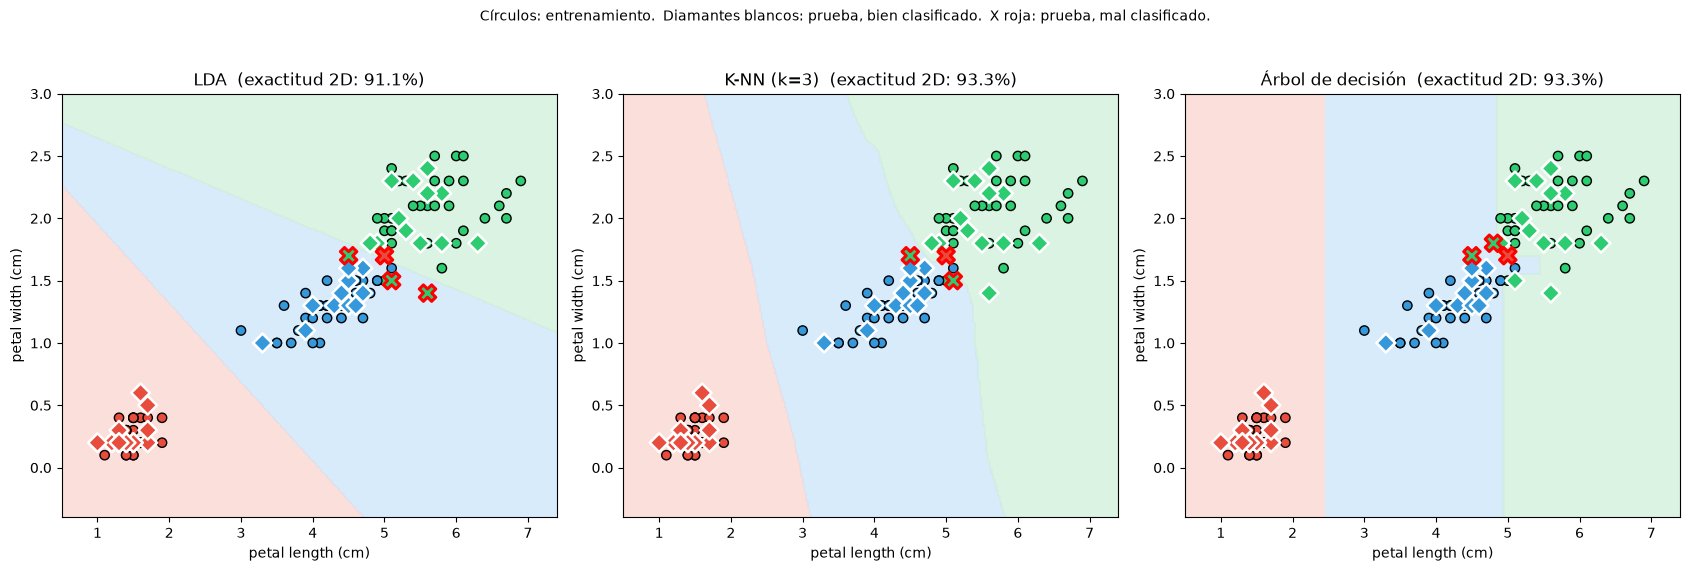

In [9]:
CMAP_FONDO = ListedColormap(["#fbd8d3", "#cfe6fa", "#d3f0dd"])
CMAP_PUNTOS = ListedColormap(colores)

x_min, x_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
y_min, y_max = X[:, 3].min() - 0.5, X[:, 3].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
malla = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

for ax, (nombre, info) in zip(axes, resumen_2d.items()):
    Z = info["modelo"].predict(malla).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=CMAP_FONDO, alpha=0.8)

    ax.scatter(X2_train[:, 0], X2_train[:, 1], c=y_train, cmap=CMAP_PUNTOS,
               edgecolor="k", s=45, label="entrenamiento")

    aciertos = modelos_2d[nombre].predict(X2_test) == y_test
    ax.scatter(X2_test[aciertos, 0], X2_test[aciertos, 1], c=y_test[aciertos],
               cmap=CMAP_PUNTOS, edgecolor="white", linewidth=1.8, s=90, marker="D")
    ax.scatter(X2_test[~aciertos, 0], X2_test[~aciertos, 1], c=y_test[~aciertos],
               cmap=CMAP_PUNTOS, edgecolor="red", linewidth=2.2, s=140, marker="X")

    ax.set_xlabel(NOMBRES_FEATURE[2]); ax.set_ylabel(NOMBRES_FEATURE[3])
    ax.set_title(f"{nombre}  (exactitud 2D: {info['acc']:.1%})")

plt.suptitle("Círculos: entrenamiento.  Diamantes blancos: prueba, bien clasificado.  "
             "X roja: prueba, mal clasificado.", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

Las tres fronteras cuentan la historia de cada algoritmo:

- **LDA** traza líneas rectas, porque busca hiperplanos lineales. La región de *versicolor* y la de *virginica* quedan separadas por una sola recta inclinada, que es la mejor recta posible pero sigue dejando algunos puntos del lado equivocado.
- **K-NN** dibuja una frontera irregular, curva, que se ajusta al detalle de dónde caen los puntos de entrenamiento. No asume ninguna forma, así que puede rodear puntos aislados con contornos pequeños.
- **Árbol de decisión** dibuja rectángulos, porque cada corte es siempre horizontal o vertical sobre una sola variable a la vez. Se nota en las esquinas rectas de sus regiones.

Las X rojas son los pocos casos que cada modelo falla, y aparecen siempre pegadas a la frontera entre *versicolor* y *virginica*, nunca dentro de una región limpia. Eso confirma que el error no es azar: es la zona donde las dos especies genuinamente se parecen.

---

## 6. Cómo decide el árbol

Al árbol se le puede pedir explícitamente la secuencia de preguntas que usó, cosa que ni LDA ni K-NN pueden mostrar.

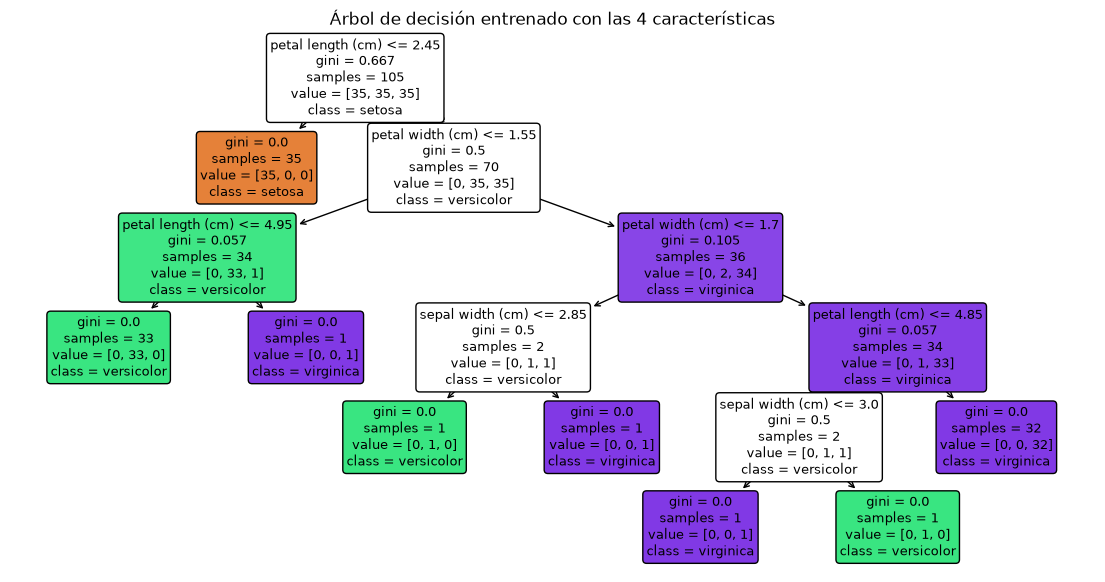

In [10]:
plt.figure(figsize=(14, 7))
plot_tree(modelos["Árbol de decisión"], feature_names=NOMBRES_FEATURE,
          class_names=NOMBRES_CLASE, filled=True, rounded=True, fontsize=9)
plt.title("Árbol de decisión entrenado con las 4 características")
plt.show()

---

## 7. Conclusiones

**Los tres coinciden en lo esencial y difieren en el detalle.** Ninguno confunde jamás a *setosa*, porque es linealmente separable de las otras dos con cualquier método. Toda la dificultad del problema, y todos los errores de los tres modelos, están concentrados en distinguir *versicolor* de *virginica*.

**La exactitud con las 4 características fue alta para los tres: LDA 97.8% (44/45), K-NN 95.6% (43/45) y el árbol 93.3% (42/45).** LDA y K-NN se comportan de forma consistente entre las dos variantes del experimento; el árbol es el que más se resiente al pasar de 4 a 2 características, porque pierde justamente las variables del sépalo que le ayudaban a resolver los pocos casos límite.

**La forma de la frontera explica el tipo de error.** LDA, al ser lineal, no puede curvarse alrededor de un caso aislado y a veces sacrifica un punto por mantener la recta simple. K-NN se adapta más al detalle local, a costa de fronteras menos suaves. El árbol, al cortar siempre en ángulo recto, necesita más cortes para aproximar una frontera diagonal, lo cual lo hace más propenso a sobreajustar si se le deja crecer sin límite.

**Sobre el uso de solo 2 variables.** Reducir a pétalo largo y ancho permite dibujar la frontera, pero descarta las mediciones del sépalo. En este dataset la pérdida de exactitud es pequeña porque el pétalo por sí solo ya casi resuelve el problema; en un dataset con más variables relevantes, esa reducción sí costaría más.